In [13]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# =========================
# 0. CONFIG & DATA LOADING
# =========================

parent_dir = os.path.dirname(os.getcwd())

# TODO: point this to your full-sample IV/RV feature file (2000–2022)
data_path = os.path.join(parent_dir, "data", "master", "iv_features_spx_2000_2022.csv")

df = pd.read_csv(data_path, parse_dates=["date"]).sort_values("date")
df = df.set_index("date")

# Assumed columns (ADAPT to your actual file):
#   rv          : daily realized variance (e.g., RS-based)
#   rv1d        : next-day realized variance target (y_{t+1})
#   vrp_30d     : 30D variance risk premium
#   ivvar_30d   : 30D implied variance level
#   vix_var     : VIX level or variance proxy
#   vix_ma5     : 5-day VIX MA
#
# If you only have rv and want to define next-day target:
# df["rv1d"] = df["rv"].shift(-1)

print("Columns in df:", df.columns.tolist())


Columns in df: ['atm_iv_10d', 'atm_iv_30d', 'atm_iv_60d', 'term_slope', 'term_curv', 'rr_25d', 'bfly_25d', 'smile_slope', 'rv30_ann', 'ivvar_30d', 'vrp_30d', 'vix_close', 'vix_open', 'vix_high', 'vix_low', 'vix9d_close', 'vix9d_open', 'vix9d_high', 'vix9d_low', 'vvix', 'vix_ret1', 'vix_ma5', 'vix9d_ret1', 'vix9d_ma5', 'vix_var', 'vrp_30d_vix', 'ivrv_ratio_vix', 'vix_minus_atmiv30']


In [18]:

# =========================
# 1. HAR-RV FEATURES
# =========================

def build_har_features(df, rv_col="rv30_ann"):
    """
    Build HAR-RV regressors:
      y_t    = target_col at t
      x1_t   = rv_{t-1}
      x5_t   = mean(rv_{t-5..t-1})
      x22_t  = mean(rv_{t-22..t-1})
    """
    out = df.copy()

    rv = out[rv_col].astype(float)

    out["rv_lag1"] = rv.shift(1)
    out["rv_lag5"] = rv.shift(1).rolling(5).mean()
    out["rv_lag22"] = rv.shift(1).rolling(22).mean()

    out["y"] = rv.shift(-1)

    # Drop rows where we don't have full lags or target
    out = out.dropna(subset=["y", "rv_lag1", "rv_lag5", "rv_lag22"])

    return out

har_df = build_har_features(df)

# Restrict sample for backtest (2002-01-01 onwards, but we need lags from before)
backtest_start = pd.Timestamp("2002-01-01")
har_df_bt = har_df.loc[har_df.index >= backtest_start].copy()


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.720e+05
Date:                Thu, 27 Nov 2025   Prob (F-statistic):               0.00
Time:                        01:56:23   Log-Likelihood:                 24324.
No. Observations:                5735   AIC:                        -4.864e+04
Df Residuals:                    5731   BIC:                        -4.861e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004   5.62e-05      7.872      0.0

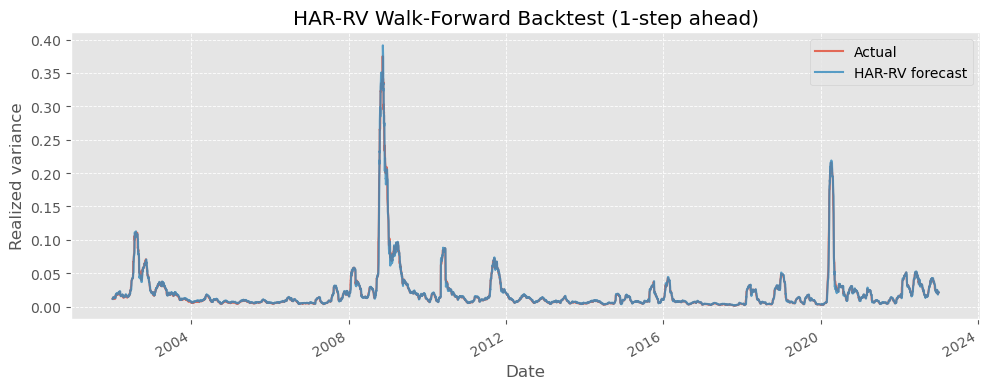

In [19]:

# =========================
# 2. HAR-RV: SINGLE FIT + WALK-FORWARD BACKTEST
# =========================

# 2.1 Simple full-sample OLS fit (for diagnostics)
X_har_full = har_df[["rv_lag1", "rv_lag5", "rv_lag22"]]
y_full = har_df["y"]

X_har_full_const = sm.add_constant(X_har_full, has_constant="add")
har_ols_full = sm.OLS(y_full, X_har_full_const).fit()
print(har_ols_full.summary())

# 2.2 Walk-forward backtest 2002-2022
def har_walk_forward_backtest(har_df, start_date):
    X_all = har_df[["rv_lag1", "rv_lag5", "rv_lag22"]]
    y_all = har_df["y"]
    dates = har_df.index

    preds = []
    actuals = []
    bt_dates = []

    for t in range(len(har_df)):
        if dates[t] < start_date:
            continue

        X_train = X_all.iloc[:t]
        y_train = y_all.iloc[:t]
        X_test = X_all.iloc[[t]]

        # Add constant
        X_train_c = sm.add_constant(X_train, has_constant="add")
        X_test_c = sm.add_constant(X_test, has_constant="add")

        model = sm.OLS(y_train, X_train_c).fit()
        y_hat_t = float(model.predict(X_test_c).iloc[0])

        preds.append(y_hat_t)
        actuals.append(float(y_all.iloc[t]))
        bt_dates.append(dates[t])

    bt_df = pd.DataFrame(
        {"y": actuals, "y_hat": preds},
        index=pd.to_datetime(bt_dates)
    )

    rmse = float(np.sqrt(mean_squared_error(bt_df["y"], bt_df["y_hat"])))
    print(f"[HAR] Walk-forward RMSE ({start_date.date()}-{bt_dates[-1].date()}): {rmse:.6f}")

    return bt_df

har_bt = har_walk_forward_backtest(har_df, backtest_start)

# Optional: plot HAR backtest
fig, ax = plt.subplots(figsize=(10, 4))
har_bt["y"].plot(ax=ax, label="Actual", alpha=0.8)
har_bt["y_hat"].plot(ax=ax, label="HAR-RV forecast", alpha=0.8)
ax.set_title("HAR-RV Walk-Forward Backtest (1-step ahead)")
ax.set_xlabel("Date")
ax.set_ylabel("Realized variance")
ax.grid(True, linestyle="--", linewidth=0.6)
ax.legend()
fig.tight_layout()
plt.show()


In [22]:

# =======================================
# 3. HMM: REGIME PROBS & TRANSITION DYNAMICS
# =======================================

# Choose features for HMM (edit these to match your file)
HMM_FEATURE_COLS = [
    "vrp_30d",    # variance risk premium
    "ivvar_30d",  # IV level
    "vix_var",    # VIX-based volatility proxy
    "vix_ma5",    # short-term VIX trend
]

# Keep only rows where these exist
hmm_df = df.dropna(subset=HMM_FEATURE_COLS + ["rv30_ann"])

X_hmm_raw = hmm_df[HMM_FEATURE_COLS].values
scaler_hmm = StandardScaler()
X_hmm = scaler_hmm.fit_transform(X_hmm_raw)

# Fit 3-state Gaussian HMM on full history
hmm_model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=200,
    random_state=42,
)
hmm_model.fit(X_hmm)

# Filtered state probabilities γ_t = P(S_t = k | X_{1:t})
gamma = hmm_model.predict_proba(X_hmm)   # shape (T, 3)
hidden_states = hmm_model.predict(X_hmm) # most likely path

# Estimate each state's "vol level" using realized variance
state_means = []
for k in range(3):
    mask_k = (hidden_states == k)
    mean_rv_k = hmm_df.loc[mask_k, "rv30_ann"].mean()
    state_means.append((k, mean_rv_k))

# Order states by average RV (low, medium, high)
state_means_sorted = sorted(state_means, key=lambda z: z[1])
state_order = {old_k: new_k for new_k, (old_k, _) in enumerate(state_means_sorted)}
print("State mean RV:", state_means_sorted)
print("State order (old -> new):", state_order)

# Re-label probabilities into ordered regimes
gamma_ordered = np.zeros_like(gamma)
for old_k, new_k in state_order.items():
    gamma_ordered[:, new_k] = gamma[:, old_k]

# Add to hmm_df
for new_k, name in enumerate(["low", "med", "high"]):
    hmm_df[f"p_regime_{name}"] = gamma_ordered[:, new_k]

# HMM transition matrix and transition dynamics
A = hmm_model.transmat_   # 3x3 matrix (old state labels)
print("Transition matrix A (old state order):\n", A)

# Re-ordered transition matrix in (low, med, high)
A_reordered = np.zeros_like(A)
for old_i, new_i in state_order.items():
    for old_j, new_j in state_order.items():
        A_reordered[new_i, new_j] = A[old_i, old_j]

print("Transition matrix in (low, med, high) order:\n", A_reordered)

# Expected duration in each regime: 1 / (1 - a_ii)
expected_durations = 1.0 / (1.0 - np.diag(A_reordered))
print("Expected duration (days) [low, med, high]:", expected_durations)

# Stationary distribution π such that πA = π
eigvals, eigvecs = np.linalg.eig(A_reordered.T)
stat_idx = np.argmin(np.abs(eigvals - 1.0))
pi = np.real(eigvecs[:, stat_idx])
pi = pi / pi.sum()
print("Stationary distribution over regimes [low, med, high]:", pi)

# Map regime probabilities back to main df (outer join on date)
df_reg = df.join(hmm_df[[f"p_regime_{name}" for name in ["low", "med", "high"]]], how="left")


State mean RV: [(2, np.float64(0.006963288875813281)), (0, np.float64(0.021860498809824117)), (1, np.float64(0.0796311482823262))]
State order (old -> new): {2: 0, 0: 1, 1: 2}
Transition matrix A (old state order):
 [[9.74147427e-01 8.79683004e-03 1.70557432e-02]
 [3.64021556e-02 9.63597844e-01 1.10204181e-88]
 [1.63396329e-02 5.50918043e-04 9.83109449e-01]]
Transition matrix in (low, med, high) order:
 [[9.83109449e-01 1.63396329e-02 5.50918043e-04]
 [1.70557432e-02 9.74147427e-01 8.79683004e-03]
 [1.10204181e-88 3.64021556e-02 9.63597844e-01]]
Expected duration (days) [low, med, high]: [59.20469989 38.68086907 27.47090062]
Stationary distribution over regimes [low, med, high]: [0.44548091 0.44116624 0.11335285]


In [24]:

# ==================================================
# 4. REGULARIZED MODEL WITH REGIME PROBABILITIES
# ==================================================

def build_reg_features(df_reg, rv_col="rv30_ann"):
    """
    Build HAR + IV + regime-probability features
    for a regularized (ElasticNet) regression.
    Target is next-day RV (or whatever you define as target_col).
    """
    out = df_reg.copy()
    rv = out[rv_col].astype(float)

    # HAR lags
    out["rv_lag1"] = rv.shift(1)
    out["rv_lag5"] = rv.shift(1).rolling(5).mean()
    out["rv_lag22"] = rv.shift(1).rolling(22).mean()

    # Target
    out["y"] = rv.shift(-1)

    # Example IV features (edit these names to match your file)
    iv_cols = ["vrp_30d", "ivvar_30d", "vix_var", "vix_ma5"]

    # Regime probabilities
    reg_cols = [f"p_regime_{name}" for name in ["low", "med", "high"]]

    all_feat_cols = ["rv_lag1", "rv_lag5", "rv_lag22"] + iv_cols + reg_cols

    out = out.dropna(subset=["y"] + all_feat_cols)

    X = out[all_feat_cols]
    y = out["y"]

    return out, X, y, all_feat_cols

reg_df, X_reg, y_reg, feature_names = build_reg_features(df_reg)

# ---- Train / Validation / Test split by date ----
# Adjust these cutoffs as you like
train_end = pd.Timestamp("2014-12-31")
val_end = pd.Timestamp("2018-12-31")

train_mask = (reg_df.index <= train_end)
val_mask = (reg_df.index > train_end) & (reg_df.index <= val_end)
test_mask = (reg_df.index > val_end)

X_train, y_train = X_reg.loc[train_mask], y_reg.loc[train_mask]
X_val, y_val = X_reg.loc[val_mask], y_reg.loc[val_mask]
X_test, y_test = X_reg.loc[test_mask], y_reg.loc[test_mask]

print("Train size:", X_train.shape, "Val size:", X_val.shape, "Test size:", X_test.shape)

# Standardize features
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_val_scaled = scaler_reg.transform(X_val)
X_test_scaled = scaler_reg.transform(X_test)

# ---- Hyperparameter tuning (alpha, l1_ratio) on train/val ----
from itertools import product

alpha_grid = np.logspace(-4, 1, 10)   # regularization strength
l1_grid = [0.1, 0.3, 0.5, 0.7, 0.9]   # 0=ridge, 1=lasso

best_cfg = None
best_val_rmse = np.inf

for alpha, l1 in product(alpha_grid, l1_grid):
    model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000, fit_intercept=True)
    model.fit(X_train_scaled, y_train.values)
    y_val_pred = model.predict(X_val_scaled)
    rmse_val = np.sqrt(mean_squared_error(y_val.values, y_val_pred))

    if rmse_val < best_val_rmse:
        best_val_rmse = rmse_val
        best_cfg = (alpha, l1)

print(f"Best (alpha, l1_ratio) = {best_cfg}, val RMSE = {best_val_rmse:.6f}")

best_alpha, best_l1 = best_cfg

# Fit final model on train+val and evaluate on test
X_trval = pd.concat([X_train, X_val], axis=0)
y_trval = pd.concat([y_train, y_val], axis=0)

X_trval_scaled = scaler_reg.fit_transform(X_trval)
X_test_scaled = scaler_reg.transform(X_test)

enet_final = ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=10000, fit_intercept=True)
enet_final.fit(X_trval_scaled, y_trval.values)

y_test_pred = enet_final.predict(X_test_scaled)
rmse_test = np.sqrt(mean_squared_error(y_test.values, y_test_pred))
print(f"[ElasticNet + regimes] Test RMSE: {rmse_test:.6f}")


Train size: (3722, 10) Val size: (1006, 10) Test size: (1007, 10)
Best (alpha, l1_ratio) = (np.float64(0.0001), 0.1), val RMSE = 0.000886
[ElasticNet + regimes] Test RMSE: 0.001860


[ElasticNet + regimes] Walk-forward RMSE (2002-01-01-2022-12-29): 0.002274


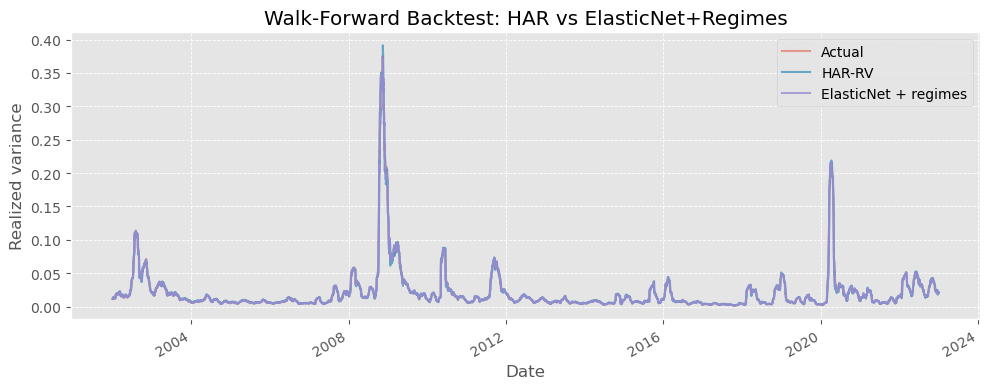

In [26]:

# ================================
# 5. WALK-FORWARD BACKTEST (2002–2022)
# ================================

def enet_walk_forward_backtest(reg_df, feature_names, alpha, l1_ratio,
                               start_date=pd.Timestamp("2002-01-01")):
    """
    Walk-forward backtest for the regularized model with fixed hyper-params.
    At each t, fit scaler+ElasticNet on all data before t, then forecast y_t.
    """
    dates = reg_df.index
    X_all = reg_df[feature_names]
    y_all = reg_df["y"]

    preds = []
    actuals = []
    bt_dates = []

    for t in range(len(reg_df)):
        if dates[t] < start_date:
            continue

        X_train = X_all.iloc[:t]
        y_train = y_all.iloc[:t]
        X_test = X_all.iloc[[t]]

        # Refit scaler on expanding window
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                           max_iter=10000, fit_intercept=True)
        model.fit(X_train_scaled, y_train.values)
        y_hat_t = float(model.predict(X_test_scaled)[0])

        preds.append(y_hat_t)
        actuals.append(float(y_all.iloc[t]))
        bt_dates.append(dates[t])

    bt_df = pd.DataFrame(
        {"y": actuals, "y_hat": preds},
        index=pd.to_datetime(bt_dates)
    )

    rmse = float(np.sqrt(mean_squared_error(bt_df["y"], bt_df["y_hat"])))
    print(f"[ElasticNet + regimes] Walk-forward RMSE ({start_date.date()}-{bt_dates[-1].date()}): {rmse:.6f}")

    return bt_df

enet_bt = enet_walk_forward_backtest(
    reg_df,
    feature_names,
    best_alpha,
    best_l1,
    start_date=backtest_start,
)

# Plot comparison vs HAR
fig, ax = plt.subplots(figsize=(10, 4))
har_bt["y"].plot(ax=ax, label="Actual", alpha=0.5)
har_bt["y_hat"].plot(ax=ax, label="HAR-RV", alpha=0.7)
enet_bt["y_hat"].plot(ax=ax, label="ElasticNet + regimes", alpha=0.8)
ax.set_title("Walk-Forward Backtest: HAR vs ElasticNet+Regimes")
ax.set_xlabel("Date")
ax.set_ylabel("Realized variance")
ax.grid(True, linestyle="--", linewidth=0.6)
ax.legend()
fig.tight_layout()
plt.show()


## Trading Strategy